In [1]:
# %% Libraries 
import os
import sys
import pandas as pd
import plotnine as p9
from pathlib import Path
import pypalettes as pp
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np

# %% Set Main Directory
MAIN_DIR_NAME = "cosmx_cf_proseg"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME

# add it to sys.path to set it as root directory
os.chdir(MAIN_DIR)

# %% Results Directories
PLOTS_DIR = Path("results/comb/spatial_polygons/FOXJ1")
print(PLOTS_DIR)

# %% CRATE code

# imports
import os
import sys
import pandas as pd
import plotnine as p9
from pathlib import Path
import pypalettes as pp
import matplotlib.colors as mcolors
import scanpy as sc
import geopandas as gpd

# create crate
def create_crate(adata_path, polygons_path, id_col):
    
    adata = sc.read_h5ad(adata_path)
    polygons = gpd.read_parquet(polygons_path)

    crate = {
        "adata": adata,
        "polygons": polygons,
        "id_col": id_col,
    }

    return crate

# subset crate
def subset_crate(crate, filter_mask):

    id_col = crate["id_col"]
    adata = crate["adata"]
    polygons = crate["polygons"]

    cells = adata.obs.index[filter_mask]
    sub_adata = adata[cells, :].copy()
    sub_polygons = polygons.loc[polygons[id_col].isin(cells)].copy()

    sub_crate = {
        "adata": sub_adata,
        "polygons": sub_polygons,
        "id_col": id_col
    }
    
    return sub_crate


results/comb/spatial_polygons/FOXJ1


In [2]:
def plot_polygons(
    crate,
    ann_var,
    fig_size=(20, 20),
    colors=None,
    cmap="viridis",
    background_color="black",
    use_raw=True,
    layer=None,
    log1p=False,
):
    import numpy as np
    import pandas as pd
    import plotnine as p9
    from scipy.sparse import issparse
    from pandas.api.types import is_numeric_dtype

    adata = crate["adata"]
    id_col = crate["id_col"]
    poly_df = crate["polygons"]

    # Read an observation annotation or gene expression
    if ann_var in adata.obs.columns:
        annotation = adata.obs[ann_var].copy()

    else:
        if use_raw:
            if adata.raw is None:
                raise ValueError("adata.raw is not available.")
            if layer is not None:
                raise ValueError(
                    "Use use_raw=False to read a layer. "
                    "adata.raw stores expression in .X."
                )
            source = adata.raw
        else:
            source = adata

        if ann_var not in source.var_names:
            location = "adata.raw.var_names" if use_raw else "adata.var_names"
            raise ValueError(f"Gene '{ann_var}' not found in {location}.")

        gene = source[:, [ann_var]]
        expression = gene.X if layer is None else gene.layers[layer]

        values = (
            expression.toarray() if issparse(expression)
            else np.asarray(expression)
        ).ravel()

        if log1p:
            values = np.log1p(values)

        annotation = pd.Series(
            values,
            index=adata.obs_names,
            name=ann_var,
        )

    # Use the ID column when available; otherwise use observation names
    cell_ids = (
        adata.obs[id_col].to_numpy()
        if id_col in adata.obs.columns
        else adata.obs_names.to_numpy()
    )

    meta_df = pd.DataFrame({id_col: cell_ids})
    meta_df["_plot_value"] = annotation.reset_index(drop=True)

    ann_poly = poly_df.merge(
        meta_df,
        on=id_col,
        how="left",
        validate="many_to_one",
    )

    # Fill scale
    if is_numeric_dtype(ann_poly["_plot_value"]):
        fill_scale = (
            p9.scale_fill_cmap(cmap_name=cmap, name=ann_var)
            if colors is None
            else p9.scale_fill_gradientn(colors=colors, name=ann_var)
        )
    else:
        fill_scale = (
            p9.scale_fill_hue(name=ann_var)
            if colors is None
            else p9.scale_fill_manual(values=colors, name=ann_var)
        )

    return (
        p9.ggplot(ann_poly)
        + p9.geom_map(
            p9.aes(geometry="geometry", fill="_plot_value"),
            color="white",
            size=0.1,
        )
        + p9.coord_fixed(1)
        + fill_scale
        + p9.theme(
            axis_line=p9.element_blank(),
            axis_text=p9.element_blank(),
            axis_ticks=p9.element_blank(),
            axis_title=p9.element_blank(),
            panel_background=p9.element_rect(fill=background_color),
            panel_grid_major=p9.element_blank(),
            panel_grid_minor=p9.element_blank(),
            figure_size=fig_size,
        )
    )

In [3]:
# %% Load adata and polygons

# Paths
OBJ_V = "cellcharter"
adata_path = Path(f"data/comb/h5ad/comb-{OBJ_V}.h5ad")
polygons_path = Path("data/comb/polygons/comb-polygons-light.parquet")
id_col = "cell_id"

# create crate
crate = create_crate(adata_path, polygons_path, id_col)

# %% get sample names
sample_names = crate["adata"].obs["sample_name"].unique()
# %% Set the annotation variable
VARS = ["FOXJ1"]



In [6]:
 crate['adata'].obs.columns

Index(['cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z',
       'component', 'volume', 'surface_area', 'scale', 'slide_ID',
       'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run',
       'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch',
       '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1',
       'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4',
       'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7',
       'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0',
       'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3',
       'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3',
       'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined',
       'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3',
       'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2',
       'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', '

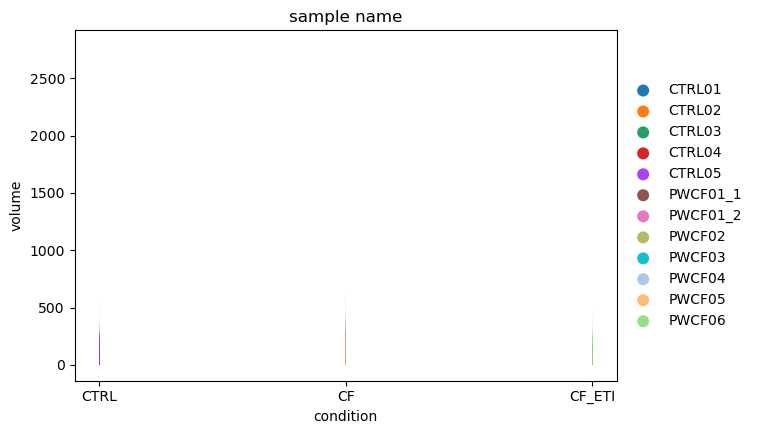

In [7]:
adata=crate['adata']
sc.pl.scatter(adata, x="condition", y="volume", color="sample_name")

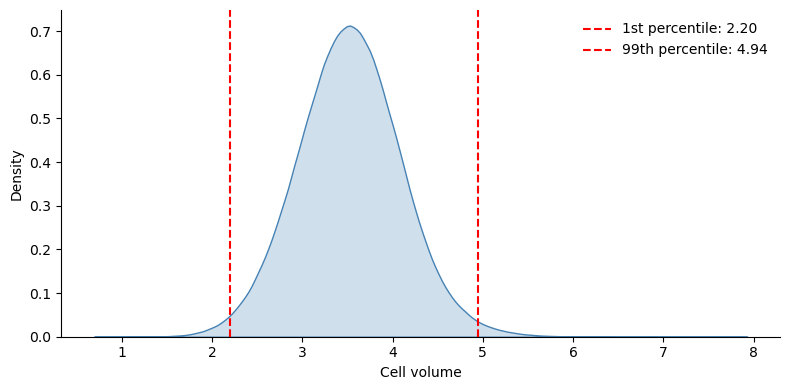

In [13]:
comb=adata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

volume = (
    np.log1p(pd.to_numeric(comb.obs["volume"], errors="coerce"))
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

p1, p99 = volume.quantile([0.01, 0.99])

fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    x=volume,
    fill=True,
    color="#4682B4",
    cut=0,
    ax=ax
)

ax.axvline(p1, color="red", linestyle="--", label=f"1st percentile: {p1:.2f}")
ax.axvline(p99, color="red", linestyle="--", label=f"99th percentile: {p99:.2f}")

ax.set_xlabel("Cell volume")
ax.set_ylabel("Density")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [16]:
crate["polygons"]

,cell,geometry,cell_id
0,0,"MULTIPOLYGON (((610 1387.08838, 610 1388.08838...",SLIDE01_0
1,1,"MULTIPOLYGON (((632 1389.08838, 632 1391.08838...",SLIDE01_1
2,2,"MULTIPOLYGON (((512 1468.08838, 512 1484.08838...",SLIDE01_2
3,3,"MULTIPOLYGON (((518 1470.08838, 518 1475.08838...",SLIDE01_3
4,4,"MULTIPOLYGON (((518 1483.08838, 518 1482.08838...",SLIDE01_4
...,...,...,...
1356375,197988,"MULTIPOLYGON (((12419 18945.08789, 12419 18944...",SLIDE04_197988
1356376,197989,"MULTIPOLYGON (((12417 18952.08789, 12417 18951...",SLIDE04_197989
1356377,197990,"MULTIPOLYGON (((12419 18958.08789, 12419 18959...",SLIDE04_197990
1356378,197991,"MULTIPOLYGON (((12426 18950.08789, 12426 18949...",SLIDE04_197991


In [25]:
import numpy as np
import pandas as pd
from shapely import wkb, wkt
from tqdm.auto import tqdm

# --------------------------------------------------
# Settings
# --------------------------------------------------
ID_COL = "cell_id"          # Unique cell ID in crate["polygons"]
GEOMETRY_COL = "geometry"

polygons = crate["polygons"]
# Exclude polygons without a cell assignment.
polygons = crate["polygons"].dropna(subset=[ID_COL]).copy()

# Match against comb.obs["cell_id"], if present;
# otherwise use comb.obs_names.
obs_ids = pd.Index(
    comb.obs[ID_COL] if ID_COL in comb.obs.columns else comb.obs_names
)

polygon_ids = pd.Index(polygons[ID_COL])

if polygon_ids.hasnans or polygon_ids.has_duplicates:
    raise ValueError("Polygon cell IDs must be unique and non-missing.")

if obs_ids.hasnans or obs_ids.has_duplicates:
    raise ValueError("AnnData cell IDs must be unique and non-missing.")

matched = obs_ids.isin(polygon_ids)

if not matched.any():
    raise ValueError(
        "No polygon IDs match comb. Check ID_COL and comb.obs_names."
    )

# Only process polygons belonging to comb.
selected = polygons.loc[
    polygon_ids.isin(obs_ids), [ID_COL, GEOMETRY_COL]
]

# --------------------------------------------------
# Calculate morphology for one cell
# --------------------------------------------------
METRICS = [
    "area",
    "perimeter",
    "circularity",
    "solidity",
    "equivalent_diameter",
    "major_length",
    "minor_length",
    "aspect_ratio",
    "orientation_deg",
    "centroid_x",
    "centroid_y",
    "n_components",
    "n_holes",
    "largest_component_fraction",
]


def measure_polygon(geometry):
    result = {f"shape_{name}": np.nan for name in METRICS}
    result["shape_status"] = "missing"

    if geometry is None:
        return result

    # Decode stored geometries when necessary.
    try:
        if isinstance(geometry, (bytes, bytearray, memoryview)):
            geometry = wkb.loads(bytes(geometry))
        elif isinstance(geometry, str):
            geometry = wkt.loads(geometry)
    except Exception:
        result["shape_status"] = "decode_error"
        return result

    if not hasattr(geometry, "geom_type"):
        result["shape_status"] = "unsupported"
        return result

    if geometry.is_empty:
        result["shape_status"] = "empty"
        return result

    if geometry.geom_type not in ("Polygon", "MultiPolygon"):
        result["shape_status"] = "non_polygon"
        return result

    # Flag invalid outlines rather than silently changing their shape.
    if not geometry.is_valid:
        result["shape_status"] = "invalid"
        return result

    area = geometry.area
    perimeter = geometry.length

    if area <= 0 or perimeter <= 0:
        result["shape_status"] = "degenerate"
        return result

    parts = (
        list(geometry.geoms)
        if geometry.geom_type == "MultiPolygon"
        else [geometry]
    )

    hull_area = geometry.convex_hull.area
    centroid = geometry.centroid

    # Minimum rotated rectangle: edge lengths and long-axis angle.
    rectangle = geometry.minimum_rotated_rectangle
    coordinates = np.asarray(rectangle.exterior.coords)[:, :2]
    edges = np.diff(coordinates, axis=0)
    lengths = np.linalg.norm(edges, axis=1)

    longest = np.argmax(lengths)
    major = lengths[longest]
    minor = lengths.min()

    orientation = (
        np.degrees(np.arctan2(edges[longest, 1], edges[longest, 0]))
        % 180
    )

    # A square rectangle has no unique long-axis orientation.
    if np.isclose(major, minor):
        orientation = np.nan

    result.update({
        "shape_area": area,
        "shape_perimeter": perimeter,
        "shape_circularity": 4 * np.pi * area / perimeter**2,
        "shape_solidity": area / hull_area,
        "shape_equivalent_diameter": 2 * np.sqrt(area / np.pi),
        "shape_major_length": major,
        "shape_minor_length": minor,
        "shape_aspect_ratio": major / minor if minor > 0 else np.nan,
        "shape_orientation_deg": orientation,
        "shape_centroid_x": centroid.x,
        "shape_centroid_y": centroid.y,
        "shape_n_components": len(parts),
        "shape_n_holes": sum(len(part.interiors) for part in parts),
        "shape_largest_component_fraction": (
            max(part.area for part in parts) / area
        ),
        "shape_status": "ok",
    })

    return result


# --------------------------------------------------
# Run and create a cell-indexed measurements table
# --------------------------------------------------
records = [
    measure_polygon(geometry)
    for geometry in tqdm(
        selected[GEOMETRY_COL],
        total=len(selected),
        desc="Measuring cell outlines",
    )
]

morphology = pd.DataFrame(
    records,
    index=pd.Index(selected[ID_COL], name=ID_COL),
)

# Align explicitly to the AnnData cell order.
aligned = morphology.reindex(obs_ids)
aligned["shape_status"] = aligned["shape_status"].fillna("no_polygon")

# Add columns without changing the existing volume column.
for column in aligned.columns:
    comb.obs[column] = aligned[column].to_numpy()

comb.obs["shape_status"] = comb.obs["shape_status"].astype("category")

print(f"Matched polygons: {matched.sum():,} / {comb.n_obs:,} cells")
print(comb.obs["shape_status"].value_counts())

# Inspect the resulting measurements.
comb.obs[
    [
        "shape_area",
        "shape_circularity",
        "shape_solidity",
        "shape_aspect_ratio",
        "shape_n_components",
        "shape_largest_component_fraction",
    ]
].head()

Measuring cell outlines: 100%|██████████| 1140953/1140953 [03:47<00:00, 5010.59it/s]


Matched polygons: 1,140,953 / 1,187,341 cells
shape_status
ok            1140953
no_polygon      46388
Name: count, dtype: int64


,shape_area,shape_circularity,shape_solidity,shape_aspect_ratio,shape_n_components,shape_largest_component_fraction
cell_id,,,,,,
SLIDE04_0,67.0,0.526217,0.887417,1.500000,1.0,1.000000
SLIDE04_2,66.0,0.391957,0.790419,1.100000,1.0,1.000000
SLIDE04_3,53.0,0.576140,0.898305,1.125000,1.0,1.000000
SLIDE04_4,257.0,0.381564,0.866779,1.175000,2.0,0.996109
SLIDE04_5,160.0,0.434823,0.869565,1.977273,1.0,1.000000


In [24]:
# there are duplicates - the cells that have "None" as cell_id b
polygons = crate["polygons"]

duplicates = polygons.loc[
    polygons["cell_id"].duplicated(keep=False)
].sort_values("cell_id")

print(f"Rows with repeated IDs: {len(duplicates):,}")
print(f"Number of repeated cell IDs: {duplicates['cell_id'].nunique():,}")

display(duplicates.head(20))

Rows with repeated IDs: 54,762
Number of repeated cell IDs: 0


,cell,geometry,cell_id
752988,376494,"MULTIPOLYGON (((14245 7160.08838, 14245 7158.0...",None
752989,376495,"MULTIPOLYGON (((14247 7169.08838, 14247 7170.0...",None
752990,376496,"MULTIPOLYGON (((14258 7168.08838, 14258 7170.0...",None
752991,376497,"MULTIPOLYGON (((14256 7162.08838, 14256 7163.0...",None
752992,376498,"MULTIPOLYGON (((14265 7163.08838, 14265 7167.0...",None
752993,376499,"MULTIPOLYGON (((14273 7047.08838, 14273 7046.0...",None
752994,376500,"MULTIPOLYGON (((14271 7051.08838, 14271 7050.0...",None
752995,376501,"MULTIPOLYGON (((14277 7050.08838, 14277 7049.0...",None
752996,376502,"MULTIPOLYGON (((14282 7046.08838, 14282 7048.0...",None
752997,376503,"MULTIPOLYGON (((14276 7062.08838, 14276 7061.0...",None


In [26]:
import pandas as pd

# 1. Identify cells without a matching polygon
missing = comb.obs["shape_status"].eq("no_polygon")

print(f"Missing polygons: {missing.sum():,} / {comb.n_obs:,}")
display(comb.obs.loc[missing].head())

# Find the name of your sample column
print([
    c for c in comb.obs.columns
    if any(term in c.lower() for term in ["sample", "slide", "patient"])
])

Missing polygons: 46,388 / 1,187,341


,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,...,shape_major_length,shape_minor_length,shape_aspect_ratio,shape_orientation_deg,shape_centroid_x,shape_centroid_y,shape_n_components,shape_n_holes,shape_largest_component_fraction,shape_status
cell_id,,,,,,,,,,,,,,,,,,,,,
SLIDE02_376494,376494,c_2_187_10,14251.185,7160.9840,0.732337,6,46.00,222.0,1.0,SLIDE02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_polygon
SLIDE02_376495,376495,c_2_178_1427,14253.485,7171.7440,0.727381,2,52.50,244.0,1.0,SLIDE02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_polygon
SLIDE02_376496,376496,c_2_178_1429,14262.030,7169.4565,0.703313,8,20.75,156.0,1.0,SLIDE02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_polygon
SLIDE02_376497,376497,c_2_187_11,14261.135,7161.8920,0.748134,2,33.50,186.0,1.0,SLIDE02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_polygon
SLIDE02_376498,376498,c_2_178_1425,14272.469,7165.4033,0.739987,7,96.75,328.0,1.0,SLIDE02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_polygon


['slide_ID', 'sample_name', 'slide_name']


In [29]:
comb.obs.loc[missing]['ann_lvl_3_refined']

cell_id
SLIDE02_376494     Club
SLIDE02_376495      MCC
SLIDE02_376496      MCC
SLIDE02_376497      MCC
SLIDE02_376498      MCC
                  ...  
SLIDE02_426982       EC
SLIDE02_426983       EC
SLIDE02_426985      Amb
SLIDE02_426986      Fib
SLIDE02_426987    lymEC
Name: ann_lvl_3_refined, Length: 46388, dtype: category
Categories (29, object): ['AT1', 'AT2', 'AlvMac', 'Amb', ..., 'actFib', 'cB', 'cLym', 'lymEC']

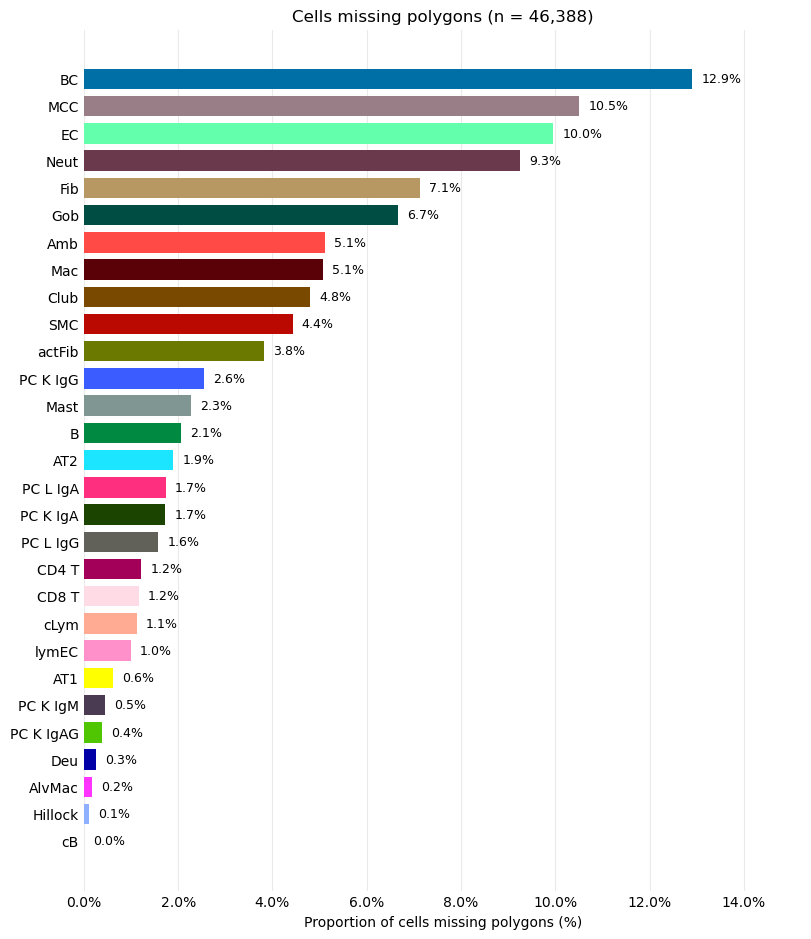

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

CELLTYPE = "ann_lvl_3_refined"

# Use your existing missing-cell mask.
labels = comb.obs.loc[missing, CELLTYPE].astype("string").fillna("Unannotated")

counts = labels.value_counts()
counts = counts[counts > 0]

if counts.empty:
    raise ValueError("No missing-polygon cells selected.")

pct = counts.div(counts.sum()).mul(100).sort_values()

# Use saved cell-type colours when available.
colour_map = {}
if (
    isinstance(comb.obs[CELLTYPE].dtype, pd.CategoricalDtype)
    and f"{CELLTYPE}_colors" in comb.uns
):
    categories = comb.obs[CELLTYPE].cat.categories
    colours = comb.uns[f"{CELLTYPE}_colors"]

    if len(categories) == len(colours):
        colour_map = dict(zip(categories.astype(str), colours))

fig, ax = plt.subplots(
    figsize=(8, max(3, 0.32 * len(pct))),
    constrained_layout=True,
)

y = np.arange(len(pct))

ax.barh(
    y,
    pct.values,
    color=[colour_map.get(c, "#777777") for c in pct.index],
    height=0.75,
)

for i, value in enumerate(pct.values):
    ax.text(
        value + pct.max() * 0.015,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_yticks(y)
ax.set_yticklabels([c.replace("_", " ") for c in pct.index])
ax.set_xlim(0, pct.max() * 1.18)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_xlabel("Proportion of cells missing polygons (%)")
ax.set_ylabel("")
ax.set_title(f"Cells missing polygons (n = {len(labels):,})")

ax.set_axisbelow(True)
ax.grid(axis="x", color="#EAEAEA")
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

In [ ]:
# qc 
# can perform qc on: volume, surface_are, scale, 

filter_mask = crate['adata'].obs

In [9]:

# %% Plot polygons

for sample in sample_names:

    print(sample)

    for ANN_VAR in VARS:

        print(ANN_VAR)

        # filter mask 
        filter_mask = crate["adata"].obs["sample_name"] == sample

        # subset crate
        sub_crate = subset_crate(crate, filter_mask)

        p = plot_polygons(sub_crate, ann_var=ANN_VAR, fig_size=(20,20))

        for ext in ['png', 'svg']:
            p.save(
                    filename= PLOTS_DIR / f'{sample}_{ANN_VAR}.{ext}',
                    dpi=900,
                    units='in'
                )

PWCF06
FOXJ1


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF06_FOXJ1.png
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF06_FOXJ1.svg


PWCF01_2
FOXJ1


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF01_2_FOXJ1.png
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF01_2_FOXJ1.svg


CTRL05
FOXJ1


...

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF05_FOXJ1.png
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF05_FOXJ1.svg


CTRL03
FOXJ1


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/CTRL03_FOXJ1.png
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/CTRL03_FOXJ1.svg


PWCF02
FOXJ1


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF02_FOXJ1.png
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 20 in image.
/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: results/comb/spatial_polygons/FOXJ1/PWCF02_FOXJ1.svg


In [1]:
## proposed qc code 

In [ ]:
import numpy as np
import pandas as pd


# ============================================================
# 1. SETTINGS
# ============================================================

# Column containing your cell-type annotations.
CELLTYPE = "ann_lvl_3_refined"

# Area thresholds:
# Cells below the 1st percentile or above the 99th percentile
# of their group will be flagged.
#
# These identify unusually small/large cells relative to their
# group. They do NOT prove that segmentation is incorrect.
LOWER_Q = 0.01
UPPER_Q = 0.99

# Fragmentation threshold:
# At least 90% of the cell's total polygon area must belong
# to its largest connected component.
#
# Example:
#   Largest component = 98% of total area -> not flagged
#   Largest component = 75% of total area -> flagged
#
# This is an adjustable exploratory cutoff, not a validated
# universal threshold.
MIN_MAIN_FRACTION = 0.90

# Only calculate an area-based outlier decision for groups
# with at least 100 cells having usable shape measurements.
#
# This avoids applying extreme percentiles to very small groups.
# It does not guarantee stable thresholds for every group.
MIN_GROUP_SIZE = 100

# Calculate area thresholds separately for each cell type.
#
# This means a fibroblast is compared with other fibroblasts,
# rather than with all cells, including much smaller populations.
GROUP_COLS = [CELLTYPE]

# Alternatively, compare cells within each SAMPLE and cell type.
# Replace "sample" with the actual sample column in comb.obs.
#
# GROUP_COLS = ["sample", CELLTYPE]


# ============================================================
# 2. IDENTIFY CELLS WITH USABLE SHAPE MEASUREMENTS
# ============================================================

# This is a reference to comb.obs, not a copy.
# Adding columns to obs below also adds them to comb.obs.
obs = comb.obs

# A cell is usable for this QC if:
#   1. Its polygon passed the geometry checks.
#   2. Its area is finite: not NaN or positive/negative infinity.
#   3. Its area is greater than zero.
#   4. Its largest-component fraction is finite.
#
# The "&" operator means that ALL conditions must be true.
valid = (
    obs["shape_status"].eq("ok")
    & np.isfinite(obs["shape_area"])
    & obs["shape_area"].gt(0)
    & np.isfinite(obs["shape_largest_component_fraction"])
)

# Keep area values for usable cells.
# Replace area values for all other cells with NaN.
#
# This prevents unassessed cells from influencing the percentiles.
# The original obs["shape_area"] column is unchanged.
area = obs["shape_area"].where(valid)


# ============================================================
# 3. CALCULATE AREA THRESHOLDS FOR EACH GROUP
# ============================================================

# Split the area values into the groups specified above.
#
# With GROUP_COLS = [CELLTYPE]:
#   One group per cell type.
#
# With GROUP_COLS = ["sample", CELLTYPE]:
#   One group per sample–cell-type combination.
#
# observed=True:
#   Use only combinations actually present in the data.
#
# dropna=False:
#   Retain cells with missing group labels as separate groups.
groups = area.groupby(
    [obs[col] for col in GROUP_COLS],
    observed=True,
    dropna=False,
)

# Calculate each group's 1st percentile.
#
# transform() returns a value for EVERY cell, in the original
# cell order. Each cell receives its own group's threshold.
#
# Example:
# If the BC group's 1st percentile is 20, every BC receives 20
# in the "lower" Series.
lower = groups.transform("quantile", q=LOWER_Q)

# Similarly, assign each cell its group's 99th percentile.
upper = groups.transform("quantile", q=UPPER_Q)

# Count the non-missing area measurements in each group.
# Cells whose area was replaced by NaN are not counted.
#
# Each cell receives the usable-cell count for its group.
group_size = groups.transform("count")

# Apply area filtering only when:
#   - the cell has usable measurements, AND
#   - its group contains enough usable cells.
#
# Small groups skip the area filter, but can still be assessed
# for fragmentation below.
assess_area = valid & group_size.ge(MIN_GROUP_SIZE)


# ============================================================
# 4. ADD SEPARATE QC FLAGS
# ============================================================

# These columns contain True or False for each cell.
# True means the cell meets that particular flagging criterion.

# Flag unusually small cells.
# .lt() means "less than".
obs["qc_shape_small"] = assess_area & area.lt(lower)

# Flag unusually large cells.
# .gt() means "greater than".
obs["qc_shape_large"] = assess_area & area.gt(upper)

# Values exactly equal to the percentile thresholds are retained.
# Because of tied values, the flagged fraction need not be
# exactly 1% at each end.

# Flag cells whose largest polygon component contains
# less than 90% of their total polygon area.
#
# This considers the SIZE of disconnected pieces, rather than
# rejecting every cell with more than one component.
#
# A cell with two components containing 99.6% and 0.4% of its
# area would therefore be retained.
obs["qc_shape_fragmented"] = (
    valid
    & obs["shape_largest_component_fraction"].lt(MIN_MAIN_FRACTION)
)

# Mark cells that could not be assessed because their required
# shape measurements were missing or unusable.
#
# "~" means NOT, so ~valid reverses the True/False values.
#
# This does not include otherwise valid cells in small groups:
# those cells can still receive a fragmentation assessment.
obs["qc_shape_unassessed"] = ~valid


# ============================================================
# 5. COMBINE THE OUTLIER FLAGS
# ============================================================

# These are the three criteria used to remove cells.
flag_cols = [
    "qc_shape_small",
    "qc_shape_large",
    "qc_shape_fragmented",
]

# Flag a cell if ANY of the three criteria is True.
#
# axis=1 means:
#   Look across the columns for each individual cell.
#
# A cell flagged for both area and fragmentation is still
# counted only once in this combined flag.
#
# Unassessed cells are NOT automatically classified as outliers.
obs["qc_shape_outlier"] = obs[flag_cols].any(axis=1)


# ============================================================
# 6. SUMMARISE HOW MANY CELLS ARE FLAGGED
# ============================================================

# For Boolean columns, sum() counts the True values:
#   True = 1
#   False = 0
summary = pd.DataFrame({
    "n_cells": obs[
        flag_cols
        + [
            "qc_shape_outlier",
            "qc_shape_unassessed",
        ]
    ].sum()
})

# Express each count as a percentage of ALL cells in comb.
summary["pct_all_cells"] = (
    100 * summary["n_cells"] / comb.n_obs
)

# The individual flags can overlap, so do not add their counts
# to calculate the total number removed.
# Use the qc_shape_outlier row for that total.
display(summary.round(2))


# ============================================================
# 7. CHECK THE EFFECT ON EACH CELL TYPE
# ============================================================

# Summarise the combined outlier flag separately by cell type.
by_celltype = (
    obs.groupby(
        CELLTYPE,
        observed=True,
        dropna=False,
    )
    .agg(
        # Total cells of this type, including unassessed cells.
        total_cells=("qc_shape_outlier", "size"),

        # Number meeting at least one outlier criterion.
        flagged_cells=("qc_shape_outlier", "sum"),
    )
)

# Percentage flagged within each cell type.
#
# Example:
#   50 flagged BCs / 1,000 total BCs × 100 = 5%
by_celltype["pct_flagged"] = (
    100
    * by_celltype["flagged_cells"]
    / by_celltype["total_cells"]
)

# Show the most affected cell types first.
# This helps identify whether the filter disproportionately
# removes particular populations.
display(
    by_celltype
    .sort_values("pct_flagged", ascending=False)
    .round(2)
)


# ============================================================
# 8. CREATE A FILTERED ANNDATA OBJECT
# ============================================================

# Keep cells that are NOT flagged as shape outliers.
#
# Unassessed cells, including those with no matching polygon,
# remain in the filtered object.
#
# .copy() creates a separate AnnData object.
# The original comb retains all cells and the added QC flags.
#
# For a large dataset, this copy can require substantial memory.
comb_filtered = comb[~obs["qc_shape_outlier"]].copy()

print(f"Before:  {comb.n_obs:,} cells")
print(f"Removed: {obs['qc_shape_outlier'].sum():,} cells")
print(f"After:   {comb_filtered.n_obs:,} cells")